# Final Pairs Trading Project

This notebook launches the complete workflow from `main.py`. Edit the **SETTINGS** section in `main.py`, then run the next cell.

Candidate symbols retained: ['BAC', 'CVX', 'FDX', 'GS', 'HD', 'JPM', 'KO', 'LOW', 'MA', 'MS', 'PEP', 'TGT', 'UPS', 'V', 'WMT', 'XOM']
Training period: 2014-01-02 to 2019-12-31
Testing period:  2020-01-02 to 2025-12-31


Selected pair using training data only:
symbol_y                      UPS
symbol_x                        V
return_correlation       0.421606
cointegration_pvalue     0.010378
adf_pvalue               0.002152
alpha                    3.206515
beta                     0.246556
half_life               41.774652
eligible                    False

Selected strategy parameters using training-period Sharpe ratio:
{
  "zscore_lookback": 60,
  "entry_zscore": 2.5,
  "exit_zscore": 0.0,
  "stop_zscore": 4.0,
  "maximum_holding_days": 60
}

FULL-PERIOD RESULTS — DESCRIPTIVE
                    Final Value  Total Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Daily Win Rate  Market Exposure  Gross Exposure  Absolute Net Exposure  

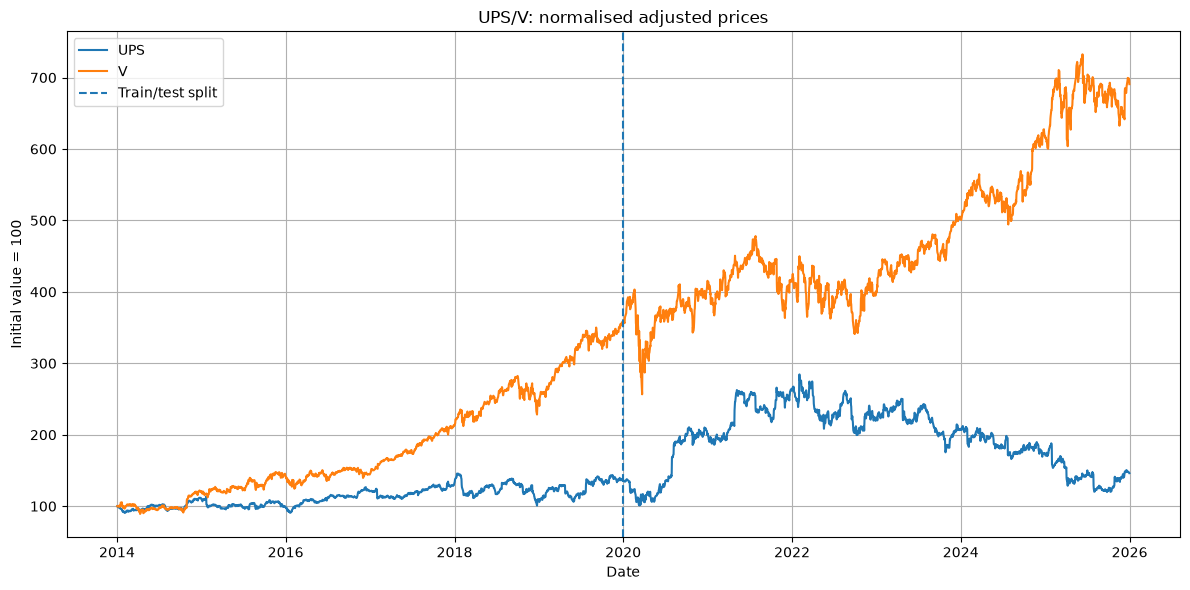

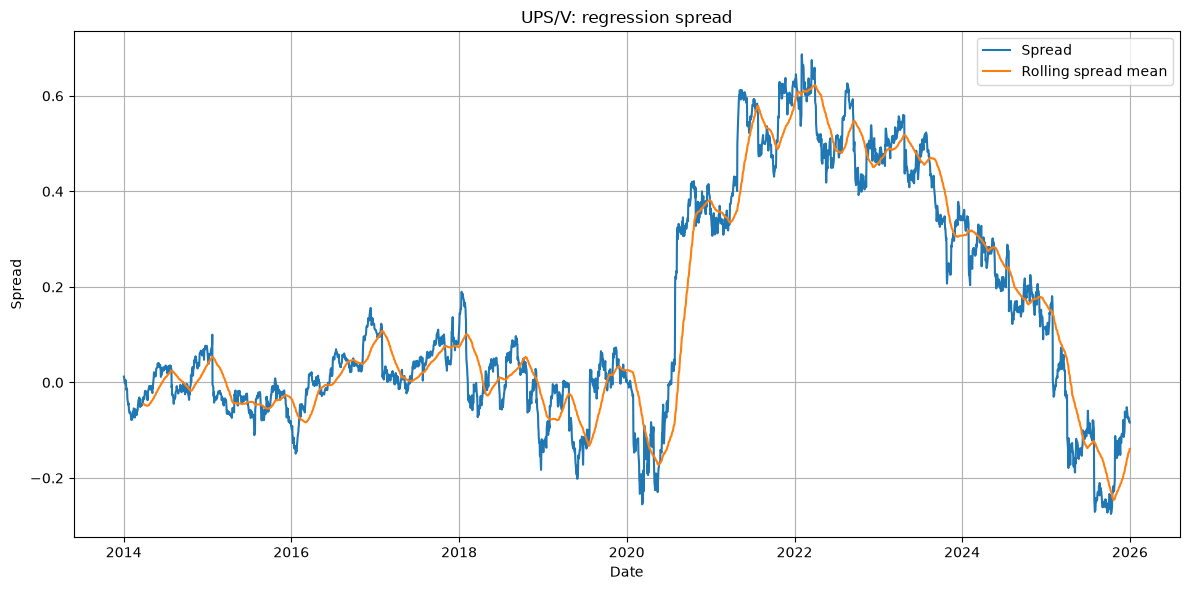

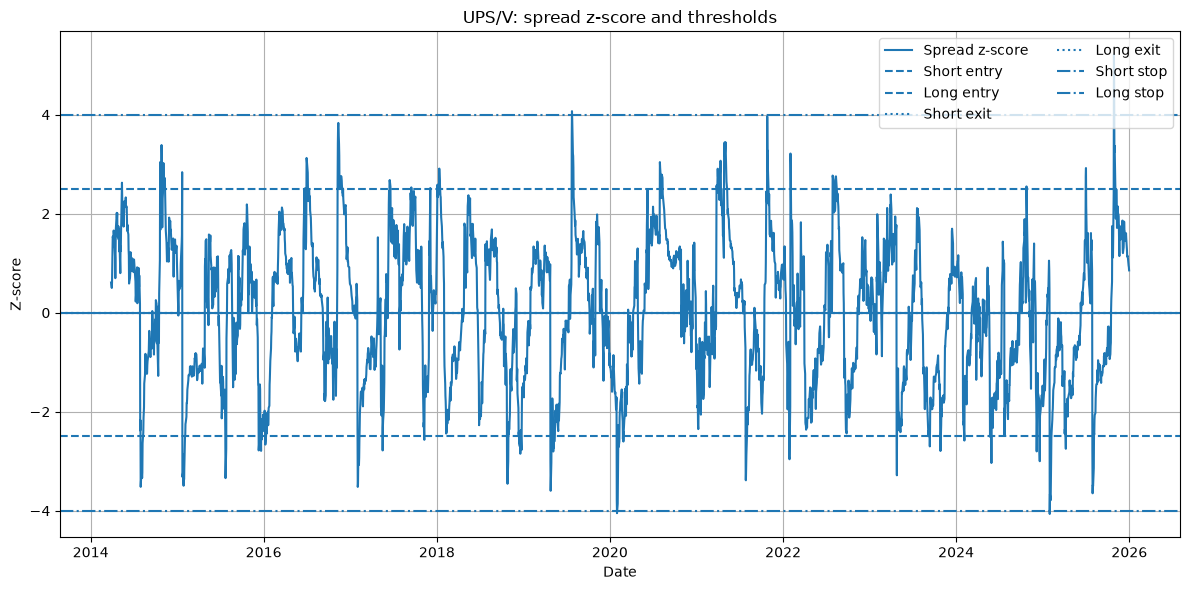

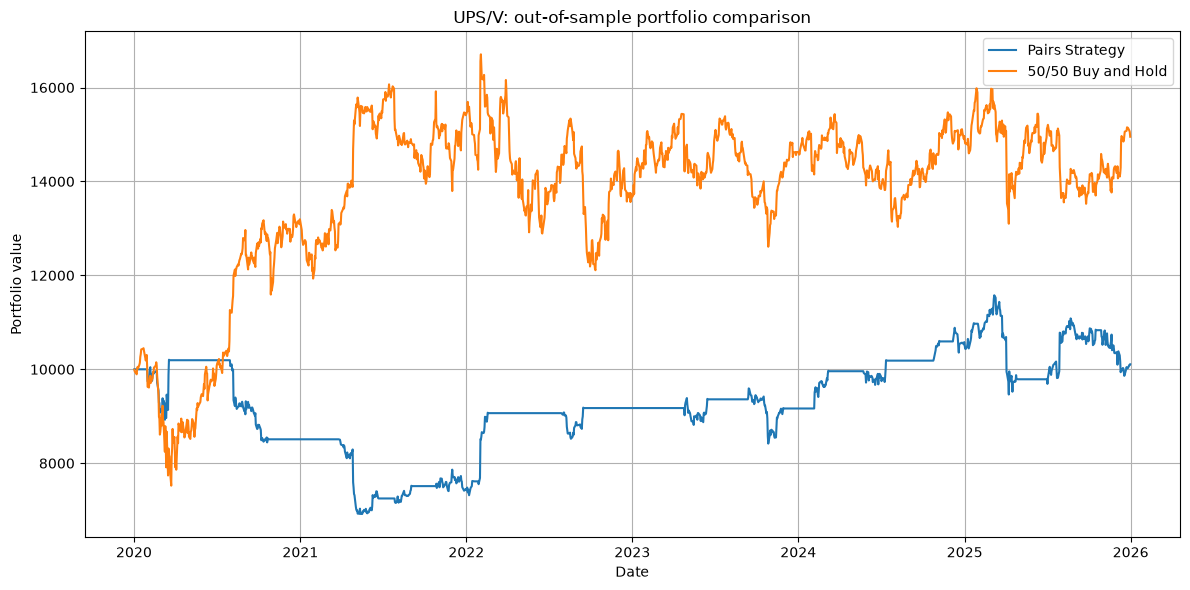

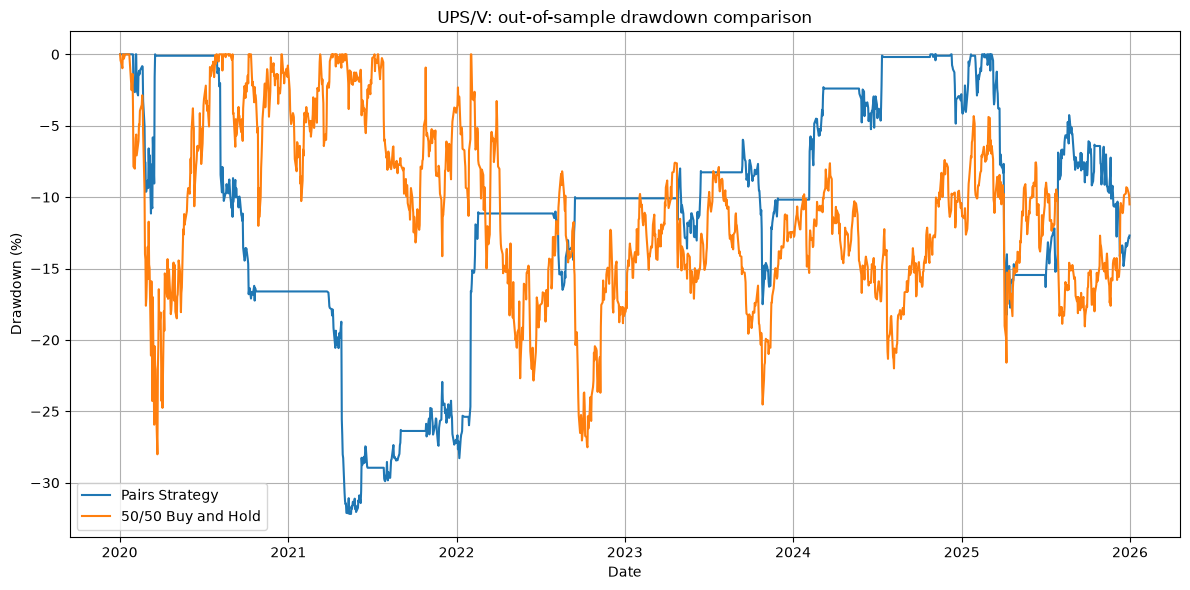

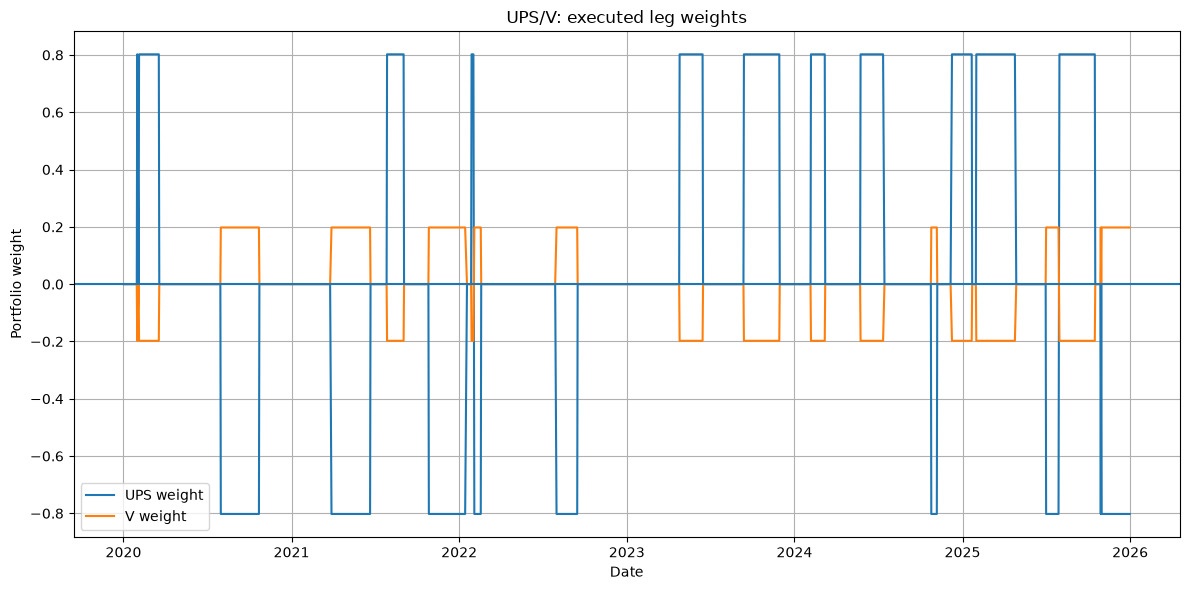


Files saved to: C:\Users\wajed\Documents\Finance_ML_projects\pairs trading\outputs
Treat the testing section as the main evidence. Pair relationships can break, shorting has operational risks, and historical profitability does not guarantee future performance.


In [1]:
import importlib
import main

importlib.reload(main)
main.SHOW_PLOTS = True

project = main.main()

## Selected pair

In [2]:
project['selected_pair'][[
    'symbol_y', 'symbol_x', 'return_correlation',
    'cointegration_pvalue', 'adf_pvalue',
    'alpha', 'beta', 'half_life', 'eligible'
]]

symbol_y                      UPS
symbol_x                        V
return_correlation       0.421606
cointegration_pvalue     0.010378
adf_pvalue               0.002152
alpha                    3.206515
beta                     0.246556
half_life               41.774652
eligible                    False
Name: 0, dtype: object

## Out-of-sample summary

In [3]:
project['summaries']['testing']

,Final Value,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Maximum Drawdown,Daily Win Rate,Market Exposure,Gross Exposure,Absolute Net Exposure,Total Turnover,Rebalance Days,Leg Orders,Completed Trades,Trade Win Rate,Average Trade Return,Average Holding Days,Profit Factor
Pairs Strategy,10107.072285,0.010707,0.001778,0.143084,0.083535,0.077307,-0.321852,0.502347,0.42374,0.42374,0.256117,39.0,39,78,19,0.684211,0.006363,31.421053,1.250648
50/50 Buy and Hold,14951.304749,0.495130,0.069383,0.243167,0.397884,0.532307,-0.280081,0.520902,1.00000,1.00000,1.000000,1.0,1,2,0,NaN,NaN,NaN,NaN


## Selected strategy parameters

In [4]:
project['selected_payload']['strategy']

{'zscore_lookback': 60,
 'entry_zscore': 2.5,
 'exit_zscore': 0.0,
 'stop_zscore': 4.0,
 'maximum_holding_days': 60}

## Top pair candidates

In [5]:
project['pair_ranking'].head(10)

,symbol_y,symbol_x,observations,return_correlation,absolute_return_correlation,cointegration_statistic,cointegration_pvalue,adf_statistic,adf_pvalue,alpha,beta,regression_r_squared,half_life,stationarity_score,eligible,use_log_prices
0,UPS,V,1510,0.421606,0.421606,-3.885753,0.010378,-3.884453,0.002152,3.206515,0.246556,0.716682,41.774652,5.072610,False,True
1,HD,UPS,1510,0.468339,0.468339,-3.678963,0.019498,-3.678195,0.004431,-6.541167,2.613171,0.754571,48.185351,4.531893,False,True
2,JPM,UPS,1510,0.486415,0.486415,-3.534495,0.029458,-3.533133,0.007176,-6.490759,2.466886,0.771176,49.160541,4.161346,False,True
3,PEP,UPS,1510,0.330123,0.330123,-3.528485,0.029952,-3.527610,0.007306,-1.182801,1.289157,0.716714,48.801584,3.990029,False,True
4,KO,PEP,1510,0.676732,0.676732,-3.289644,0.056171,-3.288550,0.015398,0.237926,0.744662,0.918797,45.736811,3.739749,False,True
5,LOW,V,1510,0.398864,0.398864,-3.217972,0.066973,-3.216971,0.019023,1.240671,0.657727,0.894869,54.585020,3.293680,False,True
6,GS,MS,1510,0.852627,0.852627,-2.956108,0.121011,-2.955080,0.039308,2.841100,0.663451,0.898919,67.942099,3.175325,False,True
7,LOW,UPS,1510,0.398442,0.398442,-3.131110,0.082224,-3.130176,0.024399,-4.275299,1.962415,0.675698,62.993937,3.096072,False,True
8,HD,LOW,1510,0.698866,0.698866,-2.982582,0.114404,-2.981379,0.036670,-0.415476,1.228053,0.949791,51.641214,3.076110,False,True
9,KO,V,1510,0.312812,0.312812,-3.156935,0.077430,-3.154492,0.022775,2.051166,0.322716,0.877351,44.802626,3.066453,False,True


## Recent out-of-sample pair trades

In [6]:
project['runs']['testing']['Pairs Strategy']['trades'].tail(10)

,entry_date,exit_date,side,entry_price_y,exit_price_y,entry_price_x,exit_price_x,entry_zscore,exit_zscore,holding_days,trade_return,status
10,2023-09-13,2023-11-30,Long Spread,135.069946,131.258072,242.692047,251.893692,-2.366378,-0.018413,55,-0.020845,Closed
11,2024-02-06,2024-03-08,Long Spread,126.331894,134.787415,271.599274,275.330597,-1.517627,0.112256,22,0.086599,Closed
12,2024-05-24,2024-07-15,Long Spread,122.744034,127.603836,270.373291,264.423981,-2.484507,0.845527,33,0.022618,Closed
13,2024-10-25,2024-11-07,Short Spread,123.204140,120.263664,278.061249,301.817810,2.185580,0.031065,9,0.040172,Closed
14,2024-12-09,2025-01-22,Long Spread,116.643539,120.291779,304.863739,319.953705,-1.663117,0.309594,28,0.035578,Closed
15,2025-01-31,2025-04-28,Long Spread,103.666008,89.372261,337.990356,334.309753,-3.665592,-1.551335,59,-0.107819,Closed
16,2025-07-02,2025-07-30,Short Spread,98.748947,81.570335,351.444000,348.159973,2.921428,-3.647626,19,0.100273,Closed
17,2025-07-31,2025-10-17,Long Spread,80.615974,82.376755,342.762604,339.807526,-3.478170,0.276333,55,0.005954,Closed
18,2025-10-29,2025-10-30,Short Spread,92.853798,90.623016,339.201233,342.928375,4.623707,3.245671,1,-0.013944,Closed
19,2025-10-31,2025-12-31,Short Spread,91.919533,96.204071,338.664520,349.264221,3.369626,0.854827,42,-0.053806,Open
